# Chapter 1: Exploratory Data Analysis

## Practical Statistics for Data Scientists

Penulis:
Peter Bruce, Andrew Bruce, Peter Gedeck

---

## Pendahuluan

Exploratory Data Analysis (EDA) atau Analisis Data Eksploratif
merupakan tahap awal dalam proses data science.

EDA bertujuan untuk memahami karakteristik dataset sebelum melakukan
pemodelan statistik maupun machine learning.

Melalui EDA, seorang data scientist dapat mengetahui:

- struktur data
- tipe variabel
- distribusi data
- nilai pusat data
- penyebaran data
- hubungan antar variabel

Pada chapter ini akan dilakukan reproduksi konsep dan implementasi
Python berdasarkan buku Practical Statistics for Data Scientists.

In [1]:
pip install wquantiles

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\TELKOM\Semester 7\DL\Tugas 1\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean
from statsmodels import robust

import wquantiles

## Struktur Data

Data dalam data science berasal dari berbagai sumber seperti:

- sensor
- transaksi
- teks
- gambar
- video

Sebelum dianalisis, data biasanya diubah menjadi bentuk terstruktur.

Bentuk data terstruktur yang umum adalah tabel yang terdiri dari:

- baris (row) sebagai record atau observasi
- kolom (column) sebagai variabel atau fitur


Jenis data:

1. Numeric
   - Continuous
   - Discrete

2. Categorical
   - Binary
   - Ordinal

In [3]:
state = pd.read_csv(
    "data/state.csv"
)

state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [ ]:
state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


## Interpretasi

Dataset terdiri dari beberapa variabel:

- State
  merupakan variabel kategorikal berupa nama wilayah.

- Population
  merupakan variabel numerik berupa jumlah penduduk.

- Murder.Rate
  merupakan variabel numerik berupa tingkat pembunuhan.

Identifikasi tipe data diperlukan agar metode statistik yang digunakan
sesuai dengan karakteristik variabel.

# Estimasi Lokasi

Estimasi lokasi digunakan untuk mengetahui nilai pusat dari data.

Ukuran yang umum digunakan:

1. Mean

Mean merupakan nilai rata-rata seluruh observasi.


2. Median

Median merupakan nilai tengah setelah data diurutkan.


3. Trimmed Mean

Trimmed mean menghitung rata-rata dengan menghilangkan sebagian
nilai ekstrem sehingga lebih tahan terhadap outlier.

In [5]:
state["Population"].mean()

6162876.3

In [6]:
trim_mean(
    state["Population"],
    0.1
)

4783697.125

In [7]:
state["Population"].median()

4436369.5

## Analisis

Nilai mean lebih besar dibandingkan median.

Hal tersebut menunjukkan bahwa terdapat beberapa wilayah dengan
jumlah penduduk sangat besar yang mempengaruhi nilai rata-rata.

Median lebih stabil ketika terdapat nilai ekstrem.

## Weighted Mean

Weighted mean memberikan bobot berbeda pada setiap observasi.

Metode ini digunakan ketika setiap data memiliki tingkat kepentingan
atau ukuran yang berbeda.

In [8]:
np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

4.445833981123393

# Estimasi Variabilitas

Variabilitas menunjukkan tingkat penyebaran data.

Ukuran yang digunakan:

- Standard deviation
- Variance
- Mean absolute deviation
- Median absolute deviation
- Interquartile range (IQR)

In [11]:
state["Population"].std()

6848235.347401142

In [12]:
state["Population"].quantile(0.75) - \
state["Population"].quantile(0.25)

4847308.0

In [13]:
robust.scale.mad(
    state["Population"]
)

3849876.1459979336

# Distribusi Data

Distribusi data menunjukkan bagaimana nilai data tersebar.

Visualisasi yang digunakan:

- Histogram
- Boxplot
- Density plot

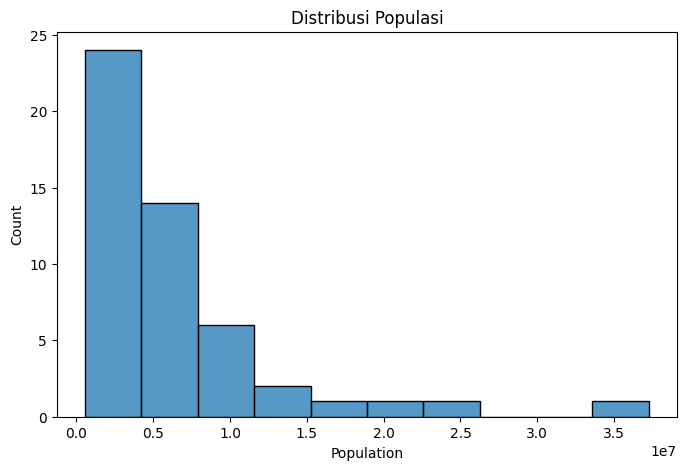

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    state["Population"],
    bins=10
)

plt.title(
    "Distribusi Populasi"
)

plt.show()

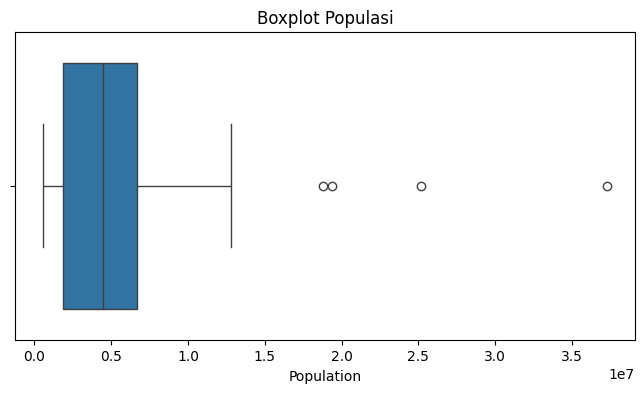

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=state["Population"]
)

plt.title(
    "Boxplot Populasi"
)

plt.show()

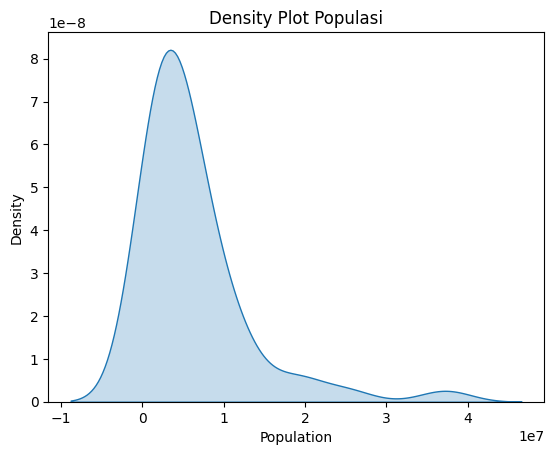

In [18]:
sns.kdeplot(
    state["Population"],
    fill=True
)

plt.title(
    "Density Plot Populasi"
)

plt.show()

# Data Kategorikal

Data kategorikal menunjukkan kelompok atau kategori tertentu.

Contoh:

- jenis kelamin
- kategori produk
- wilayah

Analisis data kategorikal dapat dilakukan menggunakan:

- frekuensi
- proporsi
- mode

# Korelasi

Korelasi digunakan untuk mengetahui hubungan antara dua variabel numerik.

Nilai korelasi berada pada rentang -1 sampai 1.

Nilai positif menunjukkan hubungan searah.

Nilai negatif menunjukkan hubungan berlawanan.

In [19]:
state[
    [
        "Population",
        "Murder.Rate"
    ]
].corr()

,Population,Murder.Rate
Population,1.000000,0.182069
Murder.Rate,0.182069,1.000000


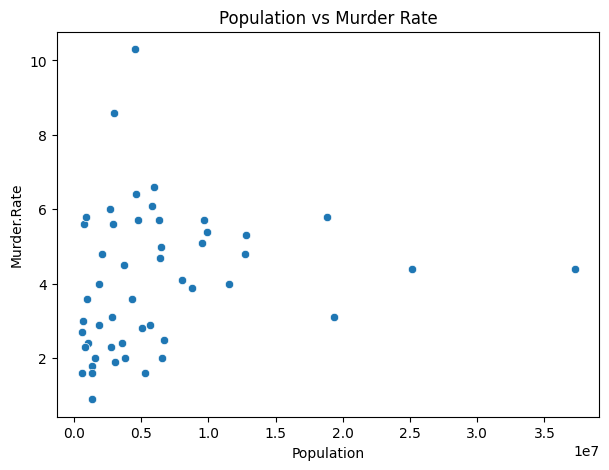

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=state,
    x="Population",
    y="Murder.Rate"
)

plt.title(
    "Population vs Murder Rate"
)

plt.show()

# Kesimpulan Chapter 1

Chapter 1 membahas Exploratory Data Analysis sebagai proses awal
untuk memahami data.

Konsep utama:

1. Mengenali struktur data.
2. Mengidentifikasi tipe variabel.
3. Mengukur lokasi data menggunakan mean dan median.
4. Mengukur penyebaran data menggunakan standar deviasi dan IQR.
5. Memahami distribusi data melalui visualisasi.
6. Menganalisis hubungan antar variabel menggunakan korelasi.

EDA membantu menentukan karakteristik data sebelum digunakan
dalam proses statistik maupun machine learning.